In [7]:
import pydicom
from pydicom.data import get_testdata_file
import matplotlib.pyplot as plt
import numpy as np

--- Patient Metadata ---
Patient Name: CompressedSamples^CT1
Patient ID:   1CT1
Modality:     CT
Study Date:   20040119

--- Engineering Specs ---
Pixel Spacing: [0.661468, 0.661468] mm


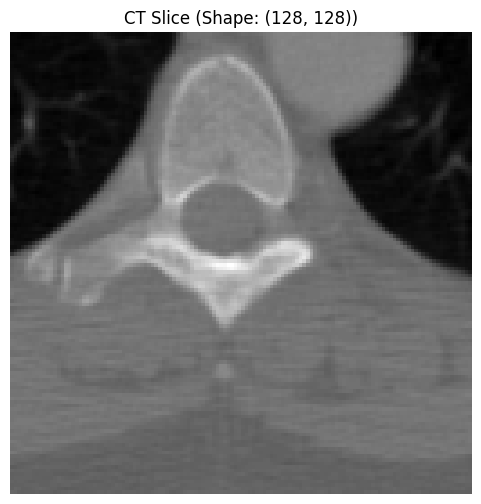

Max Pixel Value: 2191
Min Pixel Value: 128


In [ ]:
# 1. Load a Sample DICOM
# This grabs a real CT slice file included in the library
filename = get_testdata_file("CT_small.dcm")
dataset = pydicom.dcmread(filename)

# 2. Inspect the "Header" (Metadata)
# This is data you NEVER see in a JPEG
print("--- Patient Metadata ---")
# 'PatientName' is a specific DICOM tag
print(f"Patient Name: {dataset.PatientName}")
print(f"Patient ID:   {dataset.PatientID}")
print(f"Modality:     {dataset.Modality}") # (e.g., CT, MR, X-Ray)
print(f"Study Date:   {dataset.StudyDate}")


# 3. The "Hidden" Engineering Data
# Doctors need to know the physical size of each pixel to measure tumors accurately.
print("\n--- Engineering Specs ---")
# PixelSpacing = [Row Spacing, Column Spacing] in millimeters
print(f"Pixel Spacing: {dataset.PixelSpacing} mm") 
# e.g., [0.6, 0.6] means each pixel is 0.6mm wide.

# 4. Visualize the Pixel Data
# The image lives in .pixel_array
img = dataset.pixel_array

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title(f"CT Slice (Shape: {img.shape})")
plt.axis('off')
plt.show()

# 5. Check the raw values
print(f"Max Pixel Value: {img.max()}")
print(f"Min Pixel Value: {img.min()}")


In [ ]:
# Function wo window the image around HU values
def apply_window(image, center, width):
    """
    Windowing function to highlight specific tissues.
    - center (Level): The HU value we want to look at.
    - width (Window): The range of values to display.
    """
    # 1. Calculate min and max based on center/width
    img_min = center - width // 2
    img_max = center + width // 2
    
    # 2. Clamp values (Engineering term: "Clip")
    # Anything below min becomes black, anything above max becomes white.
    windowed_img = np.clip(image, img_min, img_max)
    
    return windowed_img

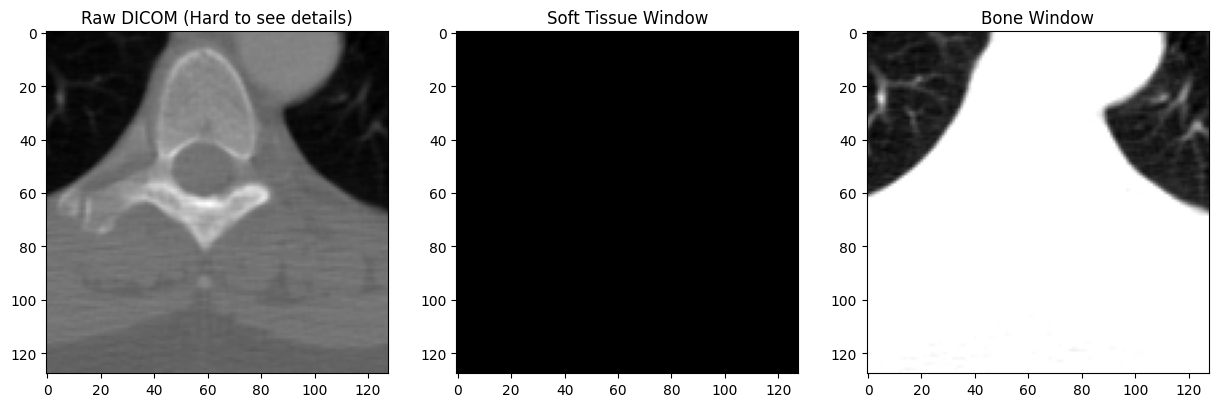

Rescale Intercept: -1024
Rescale Slope: 1


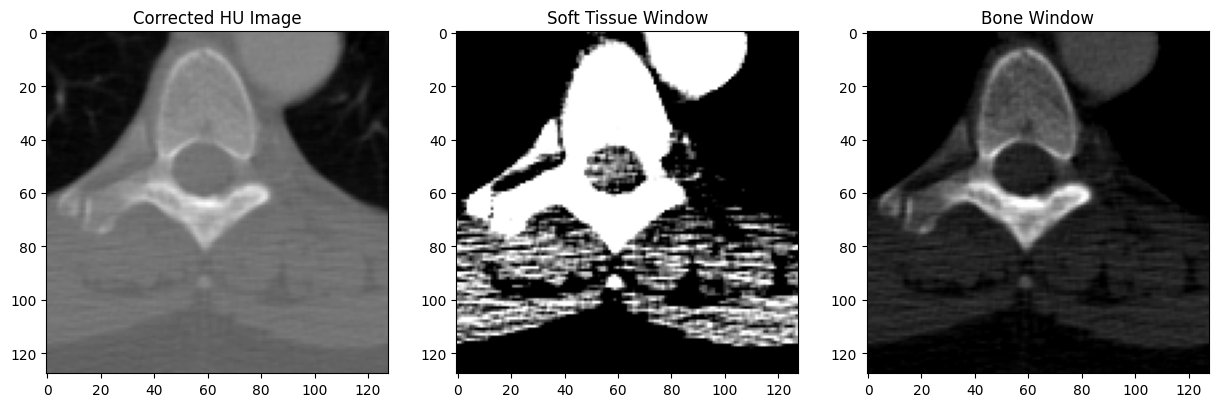

: 

In [ ]:
# --- Experiment ---
# A. Soft Tissue Window (Good for Brain/Organs)
# Center: 40 (Tissue), Width: 80
soft_tissue = apply_window(img, center=40, width=80)

# B. Bone Window (Good for Skull/Fractures)
# Center: 400 (Bone starts), Width: 1000 (High contrast)
bone = apply_window(img, center=400, width=1000)

# Visualize
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("Raw DICOM (Hard to see details)")

ax[1].imshow(soft_tissue, cmap='gray')
ax[1].set_title("Soft Tissue Window")

ax[2].imshow(bone, cmap='gray')
ax[2].set_title("Bone Window")

plt.show()

# 1. Get the Slope and Intercept
intercept = dataset.RescaleIntercept
slope = dataset.RescaleSlope

print(f"Rescale Intercept: {intercept}")
print(f"Rescale Slope: {slope}")

# 2. Convert Raw Values to Hounsfield Units (HU)
hu_image = img * slope + intercept

# 3. Re-Apply Windowing on the CORRECTED image
soft_tissue = apply_window(hu_image, center=40, width=80)
bone = apply_window(hu_image, center=400, width=1000)

# 4. Visualize
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot the HU image
ax[0].imshow(hu_image, cmap='gray')
ax[0].set_title("Corrected HU Image")

# Plot Soft Tissue (Should now see gray muscle/organs)
ax[1].imshow(soft_tissue, cmap='gray')
ax[1].set_title("Soft Tissue Window")

# Plot Bone (Should see sharp white bone structure)
ax[2].imshow(bone, cmap='gray')
ax[2].set_title("Bone Window")

plt.show()